# Master Science et Technologie de la santé - Parcours Santé Mentale Numérique

**(UE5) Stratégies thérapeutiques innovantes pour la santé mentale**

Content creator: Zaineb Amor, GHU Paris Psychiatrie et Neurosciences, INM

# MRI and fMRI Data Processing for Neuronavigated and fMRI-based TMS

This notebook outlines the workflow for processing **MRI** and **fMRI** data for **neuronavigated** and **fMRI-based TMS**.

## Workflow Steps

- **Preprocessing** is performed using **fMRIPREP**, **CHARM-TMS**, and custom Python code.  
  *Note: The fMRIPREP and CHARM-TMS steps have already been completed to save time.*
  
1. **fMRIPREP** – preprocessing anatomical and functional images  
2. **Denoising** – reducing noise from the fMRI data  
3. **h5py → txt conversion** – preparing data for further analysis  
4. **CHARM-TMS** – build head models 

- **Target Selection**: The choice of stimulation target depends on the condition:  **MDD** – targets are selected using custom Python code  

- **Target creation and export**: Finally, the selected target is **created and exported** in a format compatible with TMS machines.



In [1]:
import os
import glob
import sys

current_path = os.getcwd()          # Get current working directory
print("Current:", current_path)
parent_path = os.path.dirname(current_path)   # Go one folder up
print("Parrent:", parent_path)
os.chdir('../..')
sys.path.append(parent_path)

Current: /home/zamor/Documents/rTMS_DomenechAmor_2025/Codes/rsTMS_pipeline/notebooks
Parrent: /home/zamor/Documents/rTMS_DomenechAmor_2025/Codes/rsTMS_pipeline


In [2]:
from rsTMS_pipeline.data_loading.params import *
from rsTMS_pipeline.data_loading.loading_utils import *
from rsTMS_pipeline.preproc.preproc_utils import *
from rsTMS_pipeline.targeting.targeting_utils import *
from rsTMS_pipeline.plotting.plotting_utils import *
from nilearn import image, plotting
from nilearn.interfaces.fmriprep import load_confounds
from nilearn.image import mean_img, load_img, clean_img,index_img

**Seed-based Functional Connectivity Analysis for MDD Subjects**

This section performs the following steps for each subject and session (MDD protocol):
1. **Load fMRIPREP Data**
    - Functional (BOLD), brain masks, confound files, anatomical images, and GM masks are loaded using `load_fmriprepdata`.
    - Functional and mask files are sorted by run.

2. **Clean Functional Data**
    - For each subj/ses:
        * `clean_bold` removes confounds and performs preprocessing such as detrending and standardization.
        * The mean functional image is computed for visualization.
        * Optional: save mean cleaned BOLD images (currently commented out).
        * Export H5 → TXT** using `h5txt` to save affine transformations in a standard format for downstream analyses.

3. **Time Series Subsetting**
    - Functional data is truncated to different lengths (`time_series_lengths`) to assess stability of connectivity.
    - `index_img` is used to select the first N volumes.

4. **Seed-based Connectivity (SGC)**
    - Define a seed in SGC (coordinates: 6,16,-10) and create spherical masks.
    - Compute correlation maps between the seed and the rest of the brain using `sgc_coorelation_map`.
    - ROI-based extraction over the DLPFC using `dlpfc_masking`.
    - Identify the voxel with minimum z-value in the ROI (`min_target_roi`) and optionally visualize connectivity.

5. **Seed-based Connectivity over GM**
    - Further restrict connectivity analysis to grey matter (`min_target_gm`) to refine target selection.
    - Optional visualization of projected connectivity on surface (currently commented out).

6. **Memory Management**
    - Delete intermediate variables after each step to save memory.

Notes:
    - Output files are saved in a dedicated `figures/fmriprep` directory.
    - Visualization steps (plotting, surface projections) are currently commented out for speed but can be enabled for inspection.
    - This analysis is specific to **MDD subjects**.

SUBJECT: 1 - SESSION: 1
Run: 1


/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/image/image.py:1272: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  data = signal.clean(


/home/zamor/Documents/dataset/MDD/derivatives/fmriprep/sub-01/ses-1/anat/sub-01_ses-1_from-MNI152NLin2009cAsym_to-T1w_mode-image_xfm.h5
Matrix = 
[[ 1.054518    0.02577969  0.00701983]
 [ 0.03110373  1.1171323  -0.27725616]
 [-0.03781454  0.3517124   1.1603565 ]]

Translation vector = 
[ -5.3544927  -4.906726  -14.340232 ]

Center = 
[ 0.23592781 21.99948502  9.74520111]

Offset = 
[ -6.00290447  -4.78899748 -23.63150874]

Affine matrix = 
[[ 1.05451798e+00 -2.57796869e-02  7.01983087e-03 -6.00290447e+00]
 [-3.11037265e-02  1.11713231e+00 -2.77256161e-01 -4.78899748e+00]
 [-3.78145427e-02  3.51712406e-01  1.16035652e+00  2.36315087e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

Folder '/home/zamor/Documents/dataset/MDD/derivatives/h5_transforms/sub-01/ses-1' already exists.


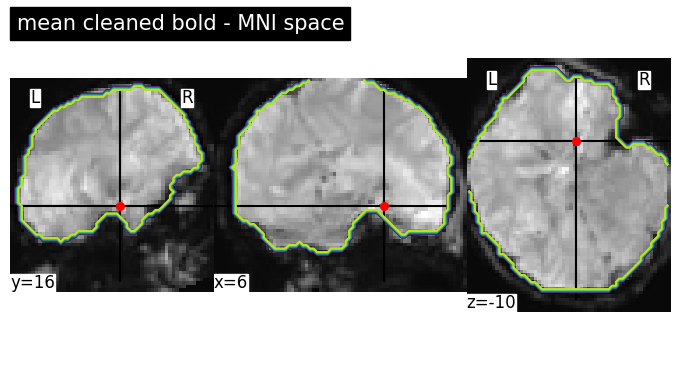

N_vols 300 Nscans: 300 SGC mask shape: (300, 1)


/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/joblib/memory.py:353: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)


NBrain voxels (300, 102301)


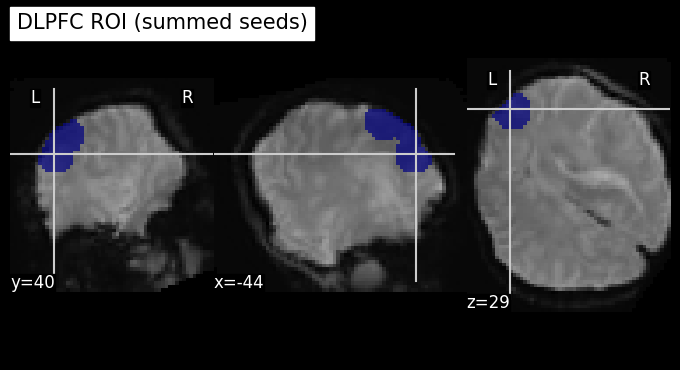

Over the DLPFC ROI
Max voxel index (in image space): (11, 54, 34)
Max Z-score value: -0.32293513415703967
Max Z-score MNI coordinates: [-47.39999795  32.7000041   16.49999857]


/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/_utils/niimg.py:61: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(


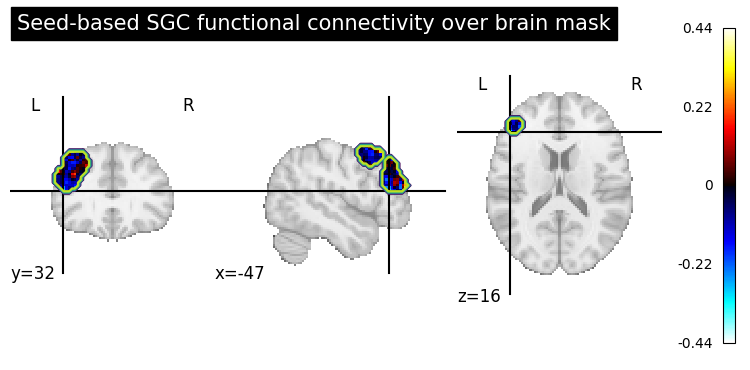

/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/surface/surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


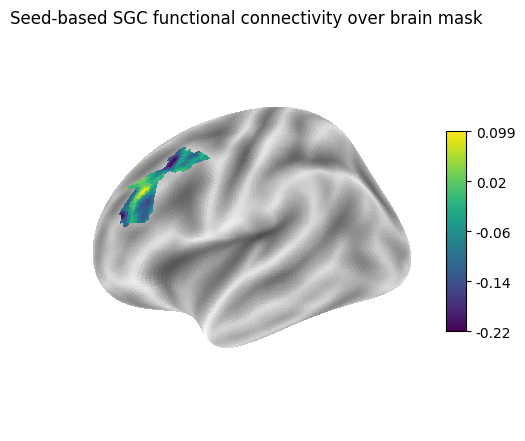

Over the DLPFC ROI  and GM
Max voxel index (in image space): (15, 59, 36)
Max Z-score value: -0.31859257170302585
Max Z-score MNI coordinates: [-36.59999776  46.20000434  21.89999866]


/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/_utils/niimg.py:61: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(


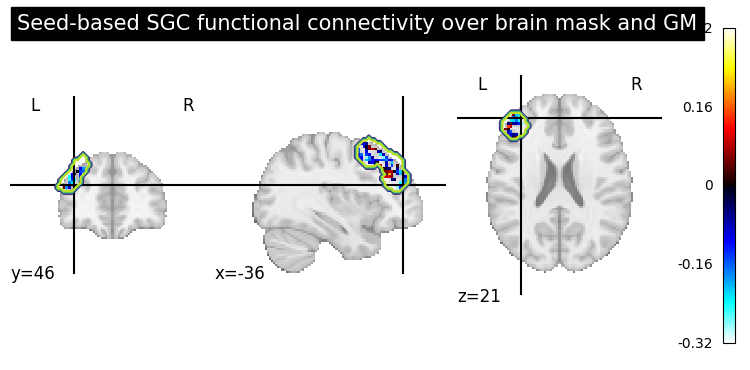

/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/surface/surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


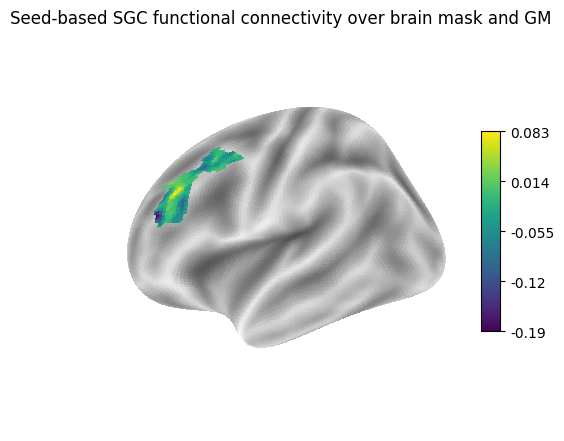

N_vols 450 Nscans: 450 SGC mask shape: (450, 1)


/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/joblib/memory.py:353: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)


NBrain voxels (450, 102301)


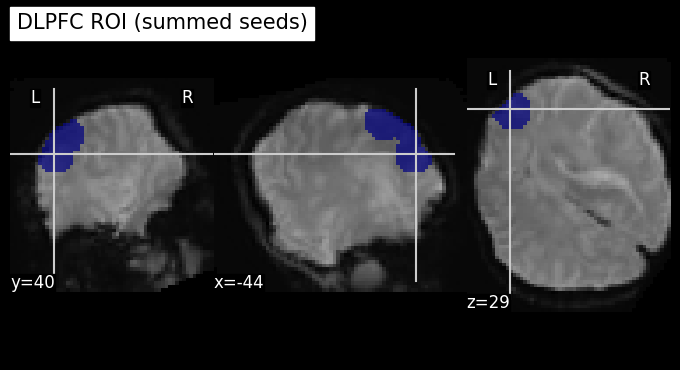

Over the DLPFC ROI
Max voxel index (in image space): (18, 60, 42)
Max Z-score value: -0.30731175134443295
Max Z-score MNI coordinates: [-28.49999762  48.90000439  38.09999895]


/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/_utils/niimg.py:61: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(


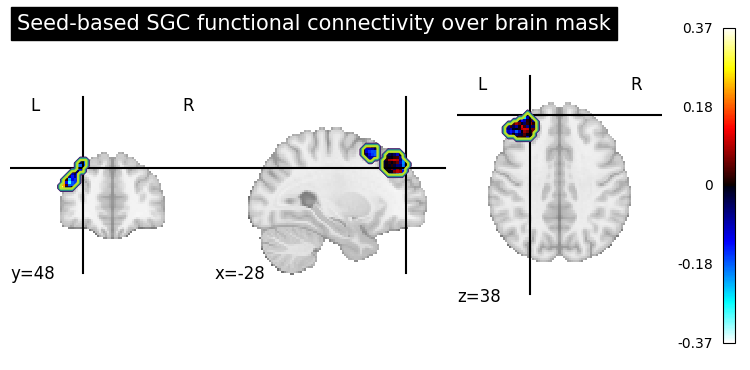

/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/surface/surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


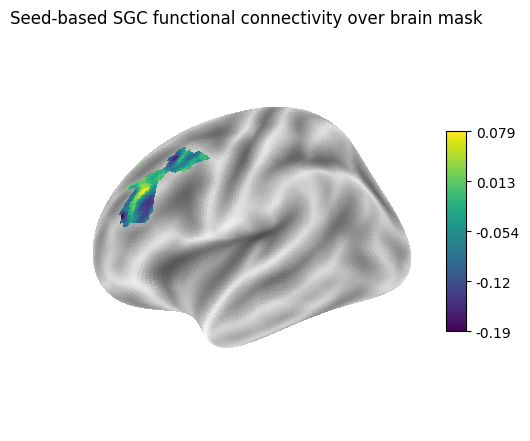

Over the DLPFC ROI  and GM
Max voxel index (in image space): (15, 46, 46)
Max Z-score value: -0.270956565721631
Max Z-score MNI coordinates: [-36.59999776  11.10000372  48.89999914]


/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/_utils/niimg.py:61: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(


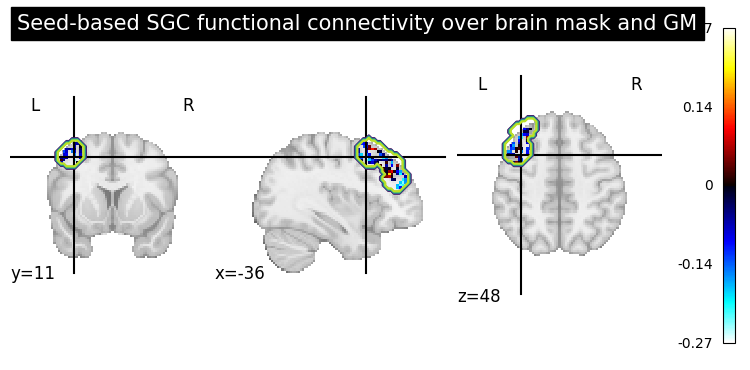

/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/surface/surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


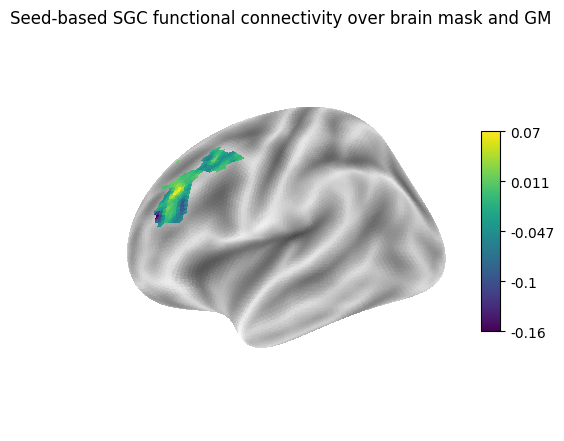

N_vols 470 Nscans: 470 SGC mask shape: (470, 1)


/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/joblib/memory.py:353: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)


NBrain voxels (470, 102301)


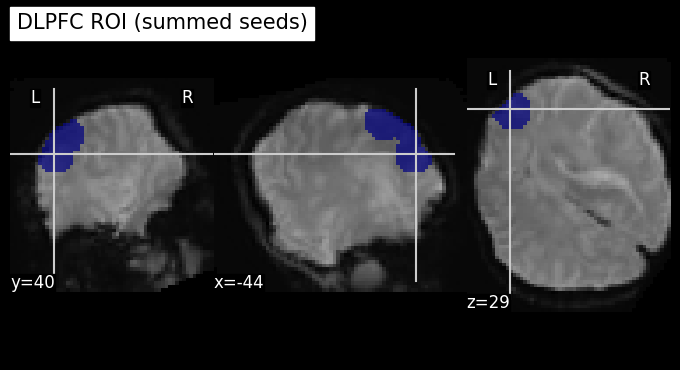

Over the DLPFC ROI
Max voxel index (in image space): (13, 60, 37)
Max Z-score value: -0.3005871839146332
Max Z-score MNI coordinates: [-41.99999785  48.90000439  24.59999871]


/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/_utils/niimg.py:61: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(


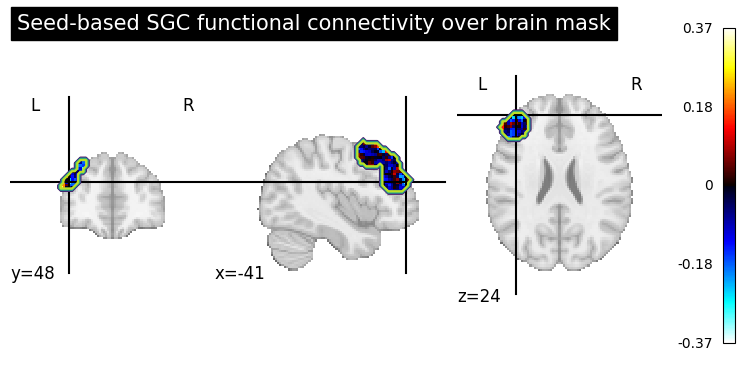

/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/surface/surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


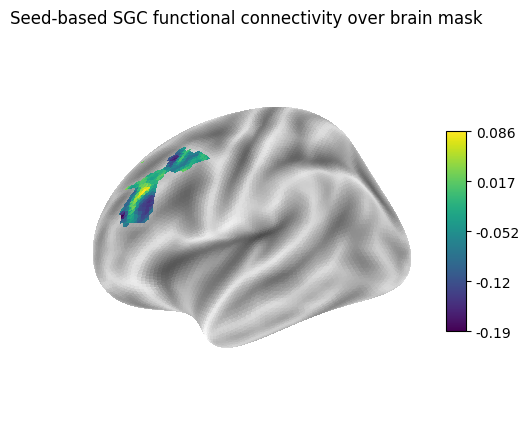

Over the DLPFC ROI  and GM
Max voxel index (in image space): (11, 59, 34)
Max Z-score value: -0.2652951839359125
Max Z-score MNI coordinates: [-47.39999795  46.20000434  16.49999857]


/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/_utils/niimg.py:61: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(


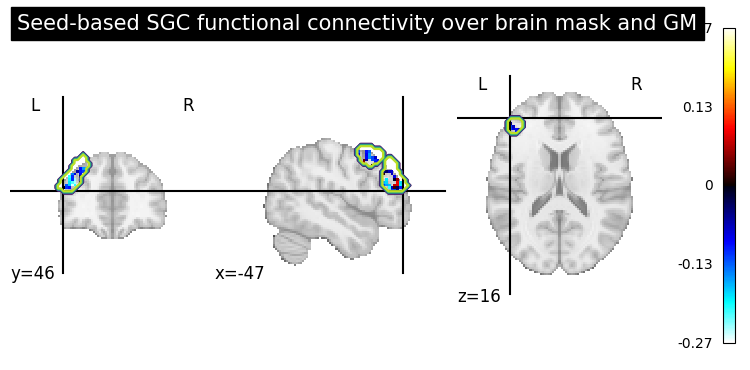

/home/team/.pyenv/versions/3.11.6/envs/compbrain/lib/python3.11/site-packages/nilearn/surface/surface.py:464: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


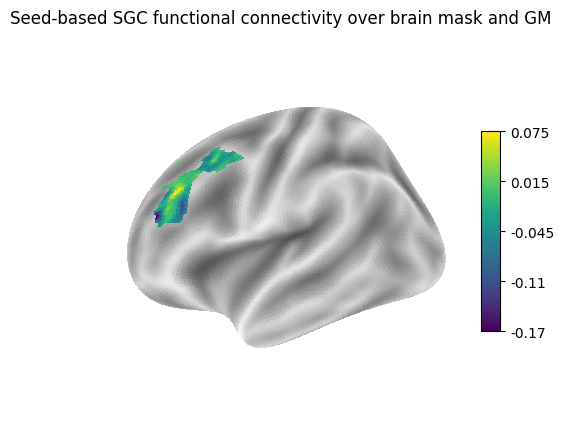

In [3]:
time_series_lengths = [300, 450, 470]
for subj in subjects: 
    for ses in sessions: 
        print('SUBJECT:', subj, '- SESSION:', ses)
        FUNC_PATH, MASK_PATH, confounds_file, ANAT_PATH, GM_PATH = load_fmriprepdata(FMRIPREP_PATH, subj, ses, space)
        bold_files = FUNC_PATH[0]
        mask_files = MASK_PATH[0]            
        fig_dir = os.path.join(FMRIPREP_PATH, 'figures')
        os.makedirs(fig_dir, exist_ok=True)
        #os.makedirs(os.path.join(FMRIPREP_PATH, 'derivatives', 'h5_transforms'), exist_ok=True)

        for i in range(len(FUNC_PATH)):
            print('Run:', i+1)
            clean_func_orig, mean_func, sample_mask, confounds = clean_bold(FUNC_PATH[i], tr=1.09)
            h5txt(FMRIPREP_PATH, TRANSFORM_PATH, subj, ses)
            
            output_file = os.path.join(fig_dir,f'subj-{subj}_ses-{ses}_run-{i+1}_mean_cleaned_bold.png')
            title = "mean cleaned bold - MNI space"
            coords=(6,16,-10)
            disp = plotting.plot_img(mean_func,cut_coords=coords,title=title,cmap="gray")
            disp.add_contours(nib.load(MASK_PATH[i]))
            disp.add_markers([coords], marker_color='red', marker_size=30)
            disp.savefig(output_file)
            plotting.show()
            
            for n_vols in time_series_lengths:
                clean_func = index_img(clean_func_orig, slice(0, n_vols))
                nscans = clean_func.shape[-1]
                sgc_masker,sgc_mask,sgc_mask_noncl = sgc_masking(FUNC_PATH[i],clean_func,nscans,radius_mm=10,seeds_sgc = [(6,16,-10)],tr=1.09)
                print('N_vols', n_vols, 'Nscans:', nscans, 'SGC mask shape:', sgc_mask.shape)
                correlation_img, correlation_map = sgc_coorelation_map(MASK_PATH[i], clean_func, sgc_mask,)
                
                roi_data, roi_img=dlpfc_masking(clean_func,MASK_PATH[i],seeds_dlpfc = [(-36,39,43), (-44,40,29), (-41,16,54)])
                output_file = os.path.join(fig_dir,
                f'subj-{subj}_ses-{ses}_run-{i+1}_nvols-{n_vols}_roi.png')
                disp_roi(roi_img, mean_func,output_file,title="DLPFC ROI (summed seeds)",coords=(-44,40,29)) 

                print('Over the DLPFC ROI')
                masked_correlation_img, min_voxel_idx, min_z_value, min_mni_coord = min_target_roi(correlation_img, roi_img)
                output_file = os.path.join(fig_dir,
                f'subj-{subj}_ses-{ses}_run-{i+1}_nvols-{n_vols}_seed_based_fc.png')
                disp_connectivity(masked_correlation_img, roi_img, output_file, title="Seed-based SGC functional connectivity over brain mask", coords=min_mni_coord)
                project_on_surf(masked_correlation_img, hemi='left',threshold=0.0, title="Seed-based SGC functional connectivity over brain mask",
                output_file = os.path.join(fig_dir,
                f'subj-{subj}_ses-{ses}_run-{i+1}_nvols-{n_vols}_seed_based_fc_LeftHemiProjection'),
                mni_coord = list(min_mni_coord))

                del(masked_correlation_img, min_voxel_idx, min_z_value, min_mni_coord)
                
                print('Over the DLPFC ROI  and GM')
                final_projected_img, min_voxel_idx, min_z_value, min_mni_coord = min_target_gm(correlation_img, roi_img,GM_PATH[0])
                output_file = os.path.join(fig_dir,
                f'subj-{subj}_ses-{ses}_run-{i+1}_nvols-{n_vols}_seed_based_fc_GM.png')
                disp_connectivity(final_projected_img, roi_img, output_file,
                title="Seed-based SGC functional connectivity over brain mask and GM", coords=min_mni_coord)
                project_on_surf(final_projected_img, hemi='left',threshold=0.0, 
                title="Seed-based SGC functional connectivity over brain mask and GM",
                output_file = os.path.join(fig_dir,
                f'subj-{subj}_ses-{ses}_run-{i+1}_nvols-{n_vols}_seed_based_fc_gm_LeftHemiProjection'),
                mni_coord = list(min_mni_coord))

                del(final_projected_img, min_voxel_idx, min_z_value, min_mni_coord)
                del(clean_func, nscans,)
